# The Autonomous Compliance Sentinel
## Goal 1

| Project | The Autonomous Compliance Sentinel |
| --- | --- |
| Modul | Responsible AI and Data Ethics |
| Authors | Group 2: Singh, Vikrant and Müller, Kay |

### 1. Sources

1. **Kaggle Jira dataset** (`cesaranasco/jira-dataset`, file `GFG_FINAL.csv`): provides **real
   issues**: project, issue type, status and the **real issue title (`Summary`)**, which is woven as a
   reference into every proposal. The dataset contains 49,000 issues.
2. **PROMISE / NFR dataset** (`PROMISE_exp`, 969 real software requirements from 47 projects):
   provides **real requirement text** and, via the classes **Security (SE)** and **Legal (L)**, the
   **data-based grounding** of a portion of the red flags.

| File | Origin | Size | Use |
| --- | --- | --- | --- |
| GFG_FINAL.csv | Kaggle Jira dataset | 114 MB | Provides the structure and vocabulary of real tickets |
| PROMISE_exp.csv | PROMISE requirements | 112 KB | Provides real requirement sentences |

## 1. Setup

**Note:** Created figures saved automatically as a .png in the `temp/` folder.

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.rcParams["figure.figsize"] = (8, 4.5); plt.rcParams["axes.titleweight"] = "bold"
print("seaborn", sns.__version__)
import os
# Store png
os.makedirs("temp", exist_ok=True)
if not getattr(plt.show, "_saves_to_temp", False):
    _fig_n = {"i": 0}
    _orig_show = plt.show
    def show(*a, **k):
        _fig_n["i"] += 1
        plt.gcf().savefig(f"temp/figure_{_fig_n['i']:02d}.png", dpi=130, bbox_inches="tight")
        return _orig_show(*a, **k)
    show._saves_to_temp = True
    plt.show = show
print("Figures are saved to the 'temp/' folder")

seaborn 0.13.2
Figures are saved to the 'temp/' folder


## 2. Load and combine data
### Jira structure and real PROMISE/NFR

In [ ]:
import os
import numpy as np
import pandas as pd
from collections import Counter

RNG = np.random.default_rng(42)

# Load PROMISE/NFR
def load_promise(path="PROMISE_exp.csv"):
    df = pd.read_csv(path).rename(columns={"RequirementText": "text", "_class_": "cls"})
    return df[["ProjectID", "text", "cls"]].dropna()

# Load Jira structure
def load_jira(path="GFG_FINAL.csv", sample=8000):
    df = pd.read_csv(path, low_memory=False)

    if "Project key" in df.columns:
        project = df["Project key"]
    else:
        project = df["Project name"]

    if "Status" in df.columns:
        status = df["Status"]
    else:
        status = pd.Series(["-"] * len(df))

    issue_type = df["Issue Type"]
    summary = df["Summary"]

    out = pd.DataFrame({
        "project": project.astype(str),
        "issue_type": issue_type.astype(str),
        "status": status.astype(str),
        "summary": summary.astype(str)
    })

    out = out.dropna()

    if sample and len(out) > sample:
        out = out.sample(sample, random_state=42)
        out = out.reset_index(drop=True)

    return out

# Red-flag catalog + mapping to NFR classes (principle, severity, NFR source | None=synthetic, synthetic violation sentences)
RED_FLAGS = {
 "RAI-01": ("Data Protection",   "High",   "L",  ["No legal basis for the data processing is documented.",
                                                  "Personal data is used without consent."]),
 "RAI-02": ("Transparency",      "High",   None, ["The automated decision is not disclosed to data subjects.",
                                                  "Users are not informed about the use of AI."]),
 "RAI-03": ("Fairness",          "High",   None, ["The target group is selected by gender.",
                                                  "Applicants are pre-filtered by origin and age."]),
 "RAI-04": ("Human Dignity",     "High",   None, ["The system deliberately exploits vulnerabilities of protected groups (e.g. children, patients).",
                                                  "Vulnerable groups are processed without special safeguards."]),
 "RAI-05": ("Prohibited Purpose","High",   None, ["The system rates people based on their social behaviour (social scoring).",
                                                  "Subliminal techniques are used to influence behaviour.",
                                                  "Employees' emotions are automatically recognised in the workplace."]),
 "RAI-06": ("Security",          "Medium", "SE", ["No security or access control is foreseen.",
                                                  "The system goes to production without a security assessment."]),
 "RAI-07": ("Human Oversight",   "Medium", None, ["The decision is made fully automatically without human intervention.",
                                                  "No human-in-the-loop is foreseen."]),
 "RAI-08": ("Data Minimization", "Medium", None, ["More data fields are collected than needed for the purpose.",
                                                  "Data is stored on stock for unknown purposes."]),
 "RAI-09": ("Explainability",    "Medium", None, ["The model is a black box without any means of justification.",
                                                  "Decisions cannot be traced or explained."]),
}
RED_FLAG_IDS = list(RED_FLAGS.keys())
NFR_TO_POLICY = {v[2]: k for k, v in RED_FLAGS.items() if v[2]}  # SE->RAI-06, L->RAI-01

def negate_requirement(text):
    return f'This requirement is NOT met: "{text.strip()}"'

# Combined generation: Jira frame + real NFR sentences, red flags partly grounded
def build_dataset(promise, jira, n=1000, rate=1/3, seed=42):
    rng = np.random.default_rng(seed)
    flagged = set(rng.choice(n, size=int(round(n*rate)), replace=False).tolist())
    by_cls = {c: promise.loc[promise.cls == c, "text"].tolist() for c in promise.cls.unique()}
    good_pool = [t for c in ["US","O","PE","A","MN","SC","FT","PO","LF"] for t in by_cls.get(c, [])]
    func_pool = by_cls.get("F", [])
    rows = []
    for i in range(n):
        jr = jira.iloc[int(rng.integers(len(jira)))]
        method = rng.choice(["Classification","Scoring","Recommender","LLM Chatbot",
                             "Clustering","Forecasting","Computer Vision"])
        body = [f"Goal: Use of {method} in project {jr['project']} ({jr['issue_type']}).",
                f"Related Jira issue [{jr['status']}]: {jr['summary']}"]
        body += [str(x) for x in rng.choice(func_pool, size=int(rng.integers(1,3)), replace=False)]
        if good_pool:
            body += [str(x) for x in rng.choice(good_pool, size=int(rng.integers(1,3)), replace=False)]
        ids = []
        if i in flagged:
            ids = sorted(rng.choice(RED_FLAG_IDS, size=int(rng.integers(1,4)), replace=False).tolist())
            for rid in ids:
                cls = RED_FLAGS[rid][2]
                if cls and by_cls.get(cls):                 
                    # grounded in a REAL (negated) requirement
                    body.append(negate_requirement(str(rng.choice(by_cls[cls]))))
                else:                                        
                    # synthetic ethical violation
                    body.append(str(rng.choice(RED_FLAGS[rid][3])))
        rng.shuffle(body)
        rows.append({"proposal_id": f"PROP-{i:04d}", "project": jr["project"],
                     "issue_type": jr["issue_type"], "ai_method": method, "description": " ".join(body),
                     "red_flags": ",".join(ids), "n_red_flags": len(ids),
                     "is_compliant": int(len(ids) == 0),
                     "grounded_flag": int(any(RED_FLAGS[r][2] for r in ids))})
    return pd.DataFrame(rows)

promise = load_promise()
jira = load_jira()
JIRA_SRC = "real (Kaggle)" if os.path.exists("GFG_FINAL.csv") else "fallback frame"
print(f"PROMISE/NFR: {promise.shape[0]} real requirements | Jira: {JIRA_SRC} ({len(jira)} real issues)")
df = build_dataset(promise, jira)
df["label"] = df["is_compliant"].map({1: "Compliant", 0: "Red Flag"})
df["word_count"] = df["description"].str.split().apply(len)
df.to_csv("proposals_1000_EN.csv", index=False)
print("Combined dataset:", df.shape, "-> proposals_1000_EN.csv")
df.head(3)

PROMISE/NFR: 969 real requirements | Jira: real (Kaggle) (8000 real issues)
Combined dataset: (1000, 11) -> proposals_1000_EN.csv


,proposal_id,project,issue_type,ai_method,description,red_flags,n_red_flags,is_compliant,grounded_flag,label,word_count
0,PROP-0000,SRCTREEWIN,Bug,LLM Chatbot,The system shall have high availability every ...,,0,1,0,Compliant,106
1,PROP-0001,SRCTREEWIN,Suggestion,Computer Vision,Related Jira issue [Gathering Interest]: Start...,,0,1,0,Compliant,95
2,PROP-0002,SRCTREEWIN,Bug,Clustering,Aside from server failure the software produc...,,0,1,0,Compliant,65


### Red-flag catalog & mapping to real NFR classes

| Policy ID | Principle | Severity | Source of the violation |
|-----------|-----------|----------|-------------------------|
| RAI-01 | Data Protection | High | **real:** negated *Legal* requirement (NFR class L) |
| RAI-02 | Transparency | High | synthetic |
| RAI-03 | Fairness | High | synthetic |
| RAI-04 | Human Dignity / Vulnerable Groups | High | synthetic |
| RAI-05 | Prohibited Purpose | High | synthetic |
| RAI-06 | Security | Medium | **real:** negated *Security* requirement (NFR class SE) |
| RAI-07 | Human Oversight | Medium | synthetic |
| RAI-08 | Data Minimization | Medium | synthetic |
| RAI-09 | Explainability | Medium | synthetic |

Compliant proposals are assembled from **real functional (F)** and **positive non-functional** NFR
sentences (Usability, Performance, Availability …) - what you might call ‘genuine’ suggestions.

## 3. The real NFR source data

In [3]:
print("PROMISE/NFR class distribution (real):")
print(promise["cls"].value_counts().to_string())
print("\nExamples Security (SE):")
for t in promise[promise.cls=="SE"]["text"].head(2): print("  -", t[:90])
print("Examples Legal (L):")
for t in promise[promise.cls=="L"]["text"].head(2): print("  -", t[:90])

PROMISE/NFR class distribution (real):
cls
F     444
SE    125
US     85
O      77
PE     67
LF     49
A      31
MN     24
SC     22
FT     18
L      15
PO     12

Examples Security (SE):
  - The product shall ensure that it can only be accessed by authorized users.  The product wi
  - Only registered realtors shall be able to access the system.
Examples Legal (L):
  - The Disputes application must conform to the legal requirements as specified by the Mercha
  - All business rules specified in the Disputes System shall be in compliance with the Mercha


## 4. Exploratory Data Analysis (EDA)

### 4.1 Class balance: compliant vs. red flag

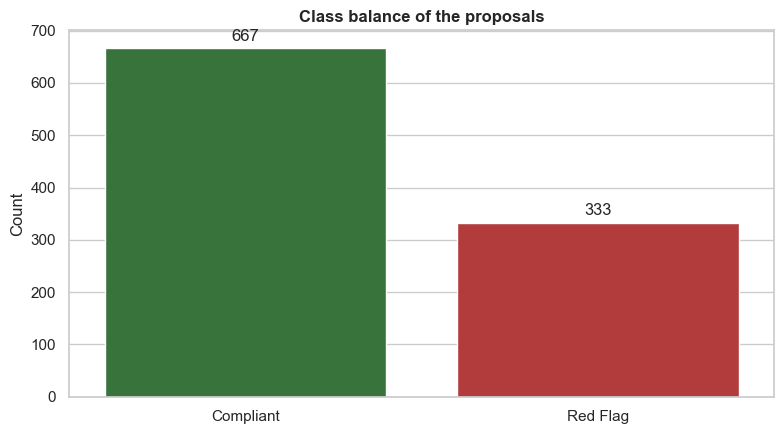

Red-flag share: 0.333


In [4]:
fig, ax = plt.subplots()
sns.countplot(data=df, x="label", order=["Compliant","Red Flag"], hue="label",
              palette={"Compliant":"#2e7d32","Red Flag":"#c62828"}, legend=False, ax=ax)
for c in ax.containers: ax.bar_label(c, fmt="%d", padding=3)
ax.set(title="Class balance of the proposals", xlabel="", ylabel="Count")
plt.tight_layout(); plt.show()
print("Red-flag share:", round(1-df["is_compliant"].mean(), 3))

**Results:** 667 compliant / 333 red flag (2:1). Import is Precision/Recall/F1, not just accuracy.

### 4.2 Frequency of red-flag types (with source labeling)

In [5]:
c = Counter()
for rf in df.loc[df.n_red_flags>0,"red_flags"]: c.update(rf.split(","))
rf_df = pd.Series(c).rename_axis("policy").reset_index(name="count").sort_values("policy")
rf_df["principle"] = rf_df["policy"].map(lambda k: RED_FLAGS[k][0])
rf_df["source"] = rf_df["policy"].map(lambda k: "real (NFR)" if RED_FLAGS[k][2] else "synthetic")
rf_df["label"] = rf_df["policy"]+"\n"+rf_df["principle"]

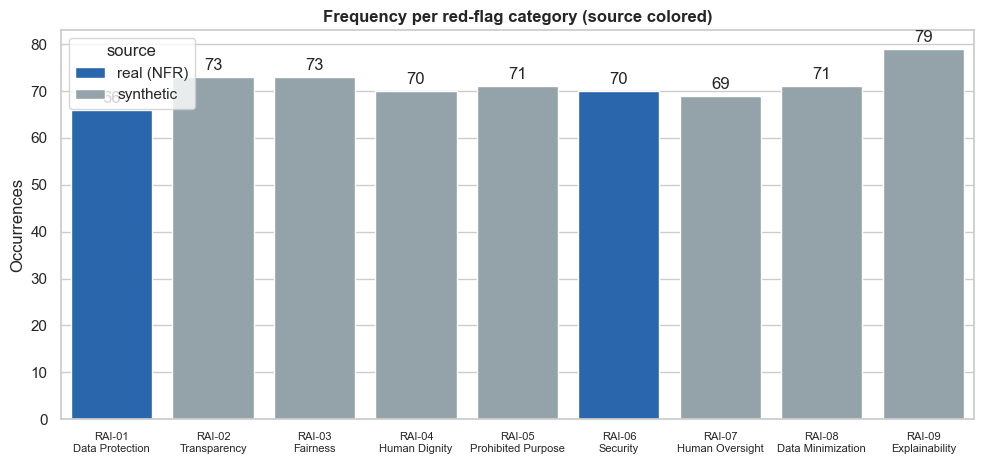

In [6]:
fig, ax = plt.subplots(figsize=(10,4.8))
sns.barplot(data=rf_df, x="label", y="count", hue="source",
            palette={"real (NFR)":"#1565c0","synthetic":"#90a4ae"}, dodge=False, ax=ax)
for cc in ax.containers: ax.bar_label(cc, fmt="%d", padding=3)
ax.set(title="Frequency per red-flag category (source colored)", xlabel="", ylabel="Occurrences")
ax.tick_params(axis="x", labelsize=8); plt.tight_layout(); plt.show()

**Results:** Categories are almost balanced. **Blue = grounded in real NFR requirements** (RAI-01/RAI-06), gray = synthetic.

### 4.3 Grounding of the red flags: real (NFR) vs. synthetic

In [7]:
g = df.loc[df.n_red_flags>0, "grounded_flag"].map({1:"at least 1 real NFR violation",0:"synthetic only"})
vc = g.value_counts()
print(vc.to_string()); print("\nGrounded share:", round(vc.get("at least 1 real NFR violation",0)/vc.sum(),3))

grounded_flag
synthetic only                   217
at least 1 real NFR violation    116

Grounded share: 0.348


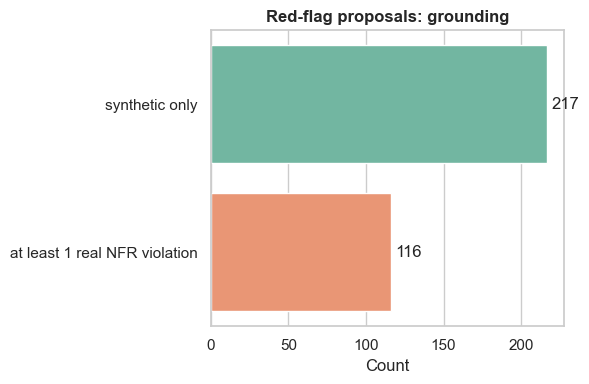

In [8]:
fig, ax = plt.subplots(figsize=(6,4))
sns.barplot(x=vc.values, y=vc.index, hue=vc.index, palette="Set2", legend=False, ax=ax)
for cc in ax.containers: ax.bar_label(cc, fmt="%d", padding=3)
ax.set(title="Red-flag proposals: grounding", xlabel="Count", ylabel=""); plt.tight_layout(); plt.show()

**Result:** A substantial part of the red-flag proposals contains **at least one real, negated NFR violation** (Security/Legal).

### 4.4 Distribution of text length

In [9]:
print(df.groupby("label")["word_count"].describe()[["mean","min","max"]].round(1))

           mean   min    max
label                       
Compliant  75.7  33.0  166.0
Red Flag   96.0  51.0  193.0


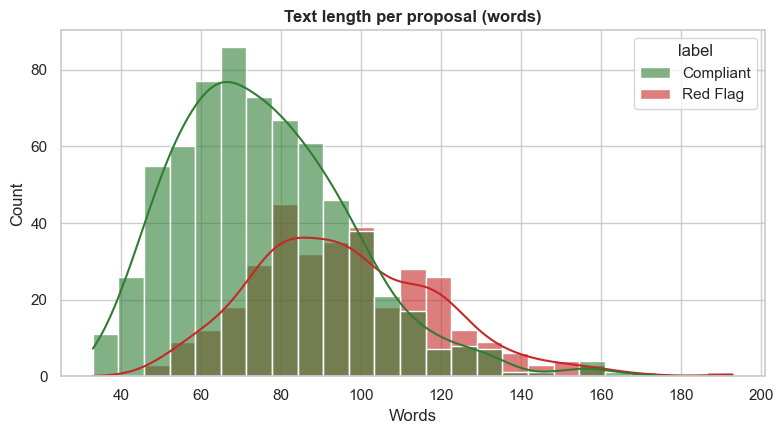

In [10]:
fig, ax = plt.subplots()
sns.histplot(data=df, x="word_count", hue="label", bins=25, kde=True,
             palette={"Compliant":"#2e7d32","Red Flag":"#c62828"}, alpha=.6, ax=ax)
ax.set(title="Text length per proposal (words)", xlabel="Words", ylabel="Count")
plt.tight_layout(); plt.show()

**Result:** Red-flag proposals are a bit longer, but text length is **not** a reliable predictor (semantic approach is needed).

### 4.5 Red-flag rate per AI method (bias check - using a fictitious group “AI method“)

*Note: the real Jira dataset contains only one project.

In [11]:
by_m = df.assign(red=1-df["is_compliant"]).groupby("ai_method")["red"].mean().sort_values().reset_index()

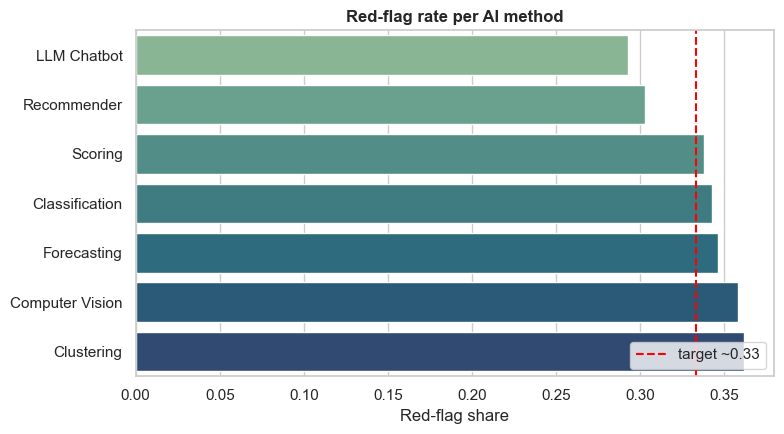

In [12]:
fig, ax = plt.subplots(figsize=(8,4.5))
sns.barplot(data=by_m, y="ai_method", x="red", hue="ai_method", palette="crest", legend=False, ax=ax)
ax.axvline(1/3, color="red", ls="--", lw=1.5, label="target ~0.33")
ax.set(title="Red-flag rate per AI method", xlabel="Red-flag share", ylabel=""); ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

**Result:** The rate fluctuates randomly around ~0.33 (**no structural data bias** by AI method)

### 4.6 Data quality

In [13]:
print("Missing values:", int(df.isna().sum().sum()))
print("Duplicates (description):", int(df["description"].duplicated().sum()))
print("Unique proposal_id:", df["proposal_id"].is_unique)
print("Example red-flag proposal:\n", df[df.n_red_flags>0].iloc[0]["description"][:300])

Missing values: 0
Duplicates (description): 0
Unique proposal_id: True
Example red-flag proposal:
 The product shall protect the identity of the players. The product shall provide players no access to information that might reveal the identity of another player. Related Jira issue [Needs Triage]: Unstaged file shows 2 extensions A failed login will alert the physician/pharmacist. Users are not in


## 5. Project plan (derived from the data analysis)

The EDA above drives the plan:

| Week | Work package | Milestone |
|------|--------------|-----------|
| 1 | Data (Jira + NFR) & EDA | Data set + analysis |
| 2 | Baseline + Risk + Fairness | Benchmark metrics |
| 3 | XAI + Tests (>= 80 %) | Evaluation report |
| 4 | LLM-Agent + RAG + Write-Back | End-to-end demo |
| 5 | Documentation + Pitch + Rehearsal | Final delivery |


## 6. Possible architecture

The Sentinel is planned as an agent pipeline. The visual diagram is in the
presentation (`Goal1_FIN.pptx`, slide 18); the same pipeline in text:

`Ingestion -> Pre-Processing -> Policy-Retrieval (RAG) -> Compliance-Engine
(Rules + ML + LLM) -> Red-Flag Classification + XAI -> Remediation-Generator ->
Human-in-the-Loop-Gate -> Write-Back + Audit-Log`

In plain terms, step by step:

* **Ingestion** - reads proposals straight from Confluence/Jira; nothing changes for the teams writing them.
* **Pre-Processing** - cleans and prepares the text for analysis.
* **Policy-Retrieval (RAG)** - pulls up only the internal rules that actually apply to this proposal.
* **Compliance-Engine (Rules + ML + LLM)** - checks the proposal three different ways, so nothing slips through a single blind spot.
* **Red-Flag Classification + XAI** - rates how serious an issue is, and explains why.
* **Remediation-Generator** - drafts a concrete suggested fix.
* **Human-in-the-Loop-Gate** - a person always approves before anything changes.
* **Write-Back + Audit-Log** - the fix is saved back, with a full record of what happened.

The data foundation built in this notebook (the labelled `proposals_1000_EN.csv`) is
the input to the **Compliance-Engine**; the RAI-01 to RAI-09 catalogue is what
**Policy-Retrieval** serves and what **Red-Flag Classification** decides against.


## 7. Regulatory analysis

Which frameworks govern a system like this, and how they apply here:

| Framework | Relevance to the Sentinel |
|-----------|---------------------------|
| **EU AI Act** | Supporting role, not high-risk as designed; the duties that apply are transparency and human oversight (the Human-in-the-Loop-Gate). |
| **GDPR / DSGVO** | Legal basis for processing, data minimisation, data subjects' rights - the very themes several RAI policies encode (RAI-01, RAI-08). |
| **ISO/IEC 42001** | AI management system: governance and risk processes around the model. |
| **ISO/IEC 23894** | AI-specific risk management, feeding the Week-2 risk analysis. |
| **NIST AI RMF** | The Govern-Map-Measure-Manage loop as an operating model for the whole lifecycle. |

The classification *"not high-risk"* holds for the system **as designed** - that is,
with a person approving every change. It rests on the Human-in-the-Loop-Gate; without
that control the risk profile would be higher.


## 2.6 Conclusion Week 1 | Goal 1

With the completion of Goal 1, the data foundation is now in place:

- 1,000 requests based on a genuine Jira structure and genuine PROMISE/NFR text.
- Some red flags are based on real factors (security, legal), whilst the rest are synthetic.
- Slight class imbalance (Recall: a missed violation is more costly than a false alarm)
- Text length is only a weak indicator, hence a semantic model.
- No structural bias according to the AI method.
- The labelled dataset is saved as proposals_1000_EN.csv and forms the handover to Week 2.

See also: **Report.docx**